In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Tanzania Climate Data - Exploratory Data Analysis

## Overview
This notebook analyzes daily climate data for Tanzania from 2015 to 2026.
The data comes from NASA POWER satellite measurements recorded at Dodoma.

The goal is to clean the data, explore temperature and rainfall trends,
and extract insights that can support Ethiopia's position at COP32.

In [5]:
df = pd.read_csv("../data/Tanzania.csv")
df["Country"] = "Tanzania"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

print("Shape:", df.shape)
df.head()

Shape: (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


## Data Loading
Tanzania dataset contains 4108 daily observations recorded at Dodoma
from January 2015 to March 2026. It has 12 columns covering temperature,
rainfall, humidity, wind speed, pressure and specific humidity.
Each row represents one day of climate measurements.

In [6]:

df.replace(-999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)

missing = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

print("\nMissing values per column:")
print(pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent.round(2)}))

Number of duplicate rows: 0

Missing values per column:
             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


## Data Cleaning
After replacing NASA's missing value code (-999) with NaN,
the Tanzania dataset showed no missing values in any column.
No duplicate rows were found either.
All 4108 daily records are usable without any data loss.

In [7]:
df.describe().round(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108,4108.00
mean,2020.13,180.12,26.80,29.16,25.04,4.13,3.74,77.13,4.11,5.19,100.80,16.92,2020-08-15 12:00:00,6.42
min,2015.00,1.00,22.68,25.41,20.03,0.94,0.00,60.06,1.12,1.55,100.15,11.38,2015-01-01 00:00:00,1.00
25%,2017.00,86.00,25.67,28.09,23.71,3.33,0.11,73.17,3.41,4.38,100.57,15.34,2017-10-23 18:00:00,3.00
50%,2020.00,179.00,26.99,29.08,25.38,4.22,0.64,76.59,4.19,5.25,100.76,17.22,2020-08-15 12:00:00,6.00
75%,2023.00,272.00,27.90,30.17,26.31,4.94,3.79,81.10,4.83,5.98,101.04,18.42,2023-06-08 06:00:00,9.00
max,2026.00,366.00,29.97,33.93,28.01,7.59,122.65,91.10,8.40,11.74,101.51,21.51,2026-03-31 00:00:00,12.00
std,3.25,106.29,1.33,1.37,1.54,1.10,8.00,5.07,1.06,1.22,0.28,1.88,NaN,3.48


## Summary Statistics
Tanzania has a mean temperature of 26.80°C and very high humidity 
of 77.13%. The maximum rainfall of 122.65mm is the highest recorded 
across all 5 countries showing Tanzania experiences intense rainfall 
events. This reflects Tanzania's tropical coastal climate.

In [8]:
columns_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z_scores = df[columns_to_check].apply(stats.zscore)
outlier_mask = (z_scores.abs() > 3)
outlier_count = outlier_mask.any(axis=1).sum()

print("Total outlier rows detected:", outlier_count)
print("\nOutliers per column:")
print(outlier_mask.sum())

Total outlier rows detected: 97

Outliers per column:
T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64


## Outlier Detection
97 outlier rows detected, mostly in rainfall (81 outliers).
Decision: Keep all outliers as they represent real extreme weather
events important for climate analysis.

In [9]:
df.to_csv("../data/tanzania_clean.csv", index=False)
print("Cleaned data saved")

Cleaned data saved


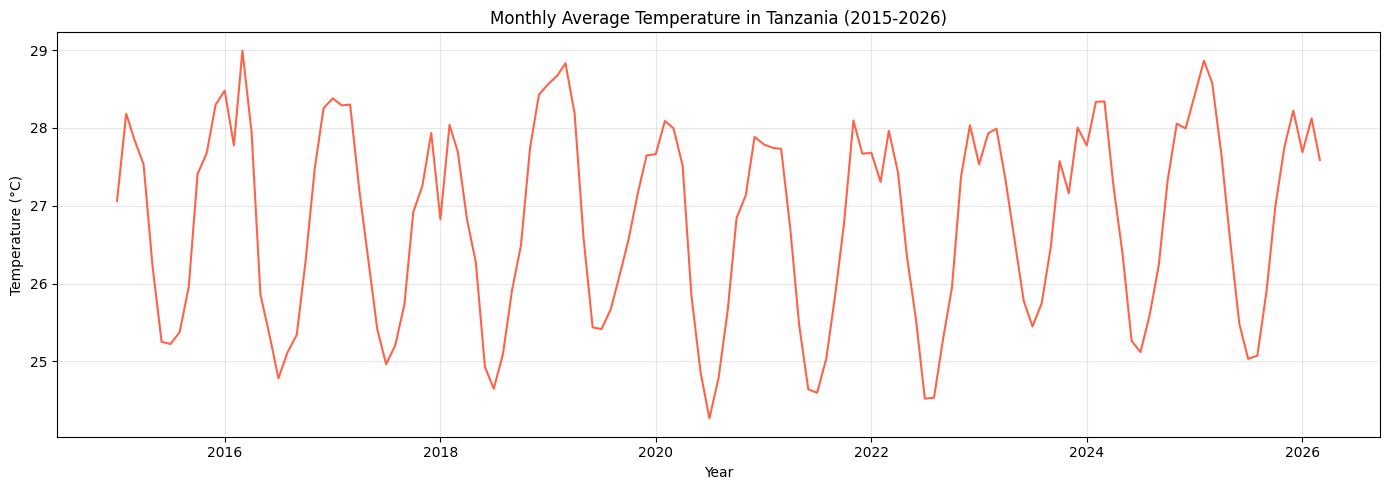

In [10]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato", linewidth=1.5)
plt.title("Monthly Average Temperature in Tanzania (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Trend (2015-2026)
Tanzania has a warm and stable temperature around 26.80°C throughout 
the year with less seasonal variation than Ethiopia or Sudan.

Key observations:
- Temperature stays relatively consistent year round
- Slight cooling visible during the main rainy season
- A gradual warming trend is visible over the 11 year period
- Rising temperatures threaten Tanzania's agriculture and ecosystems

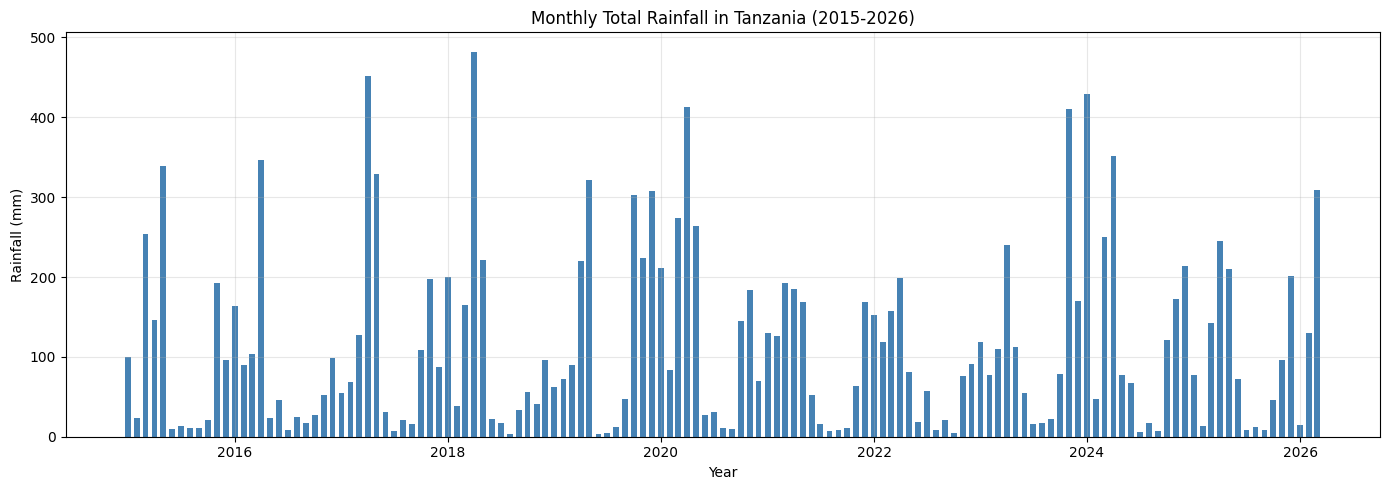

In [11]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_rain["Date"] = pd.to_datetime(monthly_rain[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_rain["Date"], monthly_rain["PRECTOTCORR"], color="steelblue", width=20)
plt.title("Monthly Total Rainfall in Tanzania (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rainfall Trend (2015-2026)
Tanzania receives significantly more rainfall than Sudan with a 
maximum single day rainfall of 122.65mm.

Key observations:
- Clear rainy seasons visible each year
- High variability between years showing climate instability
- Some years show extreme rainfall spikes representing flood risk
- Irregular rainfall patterns threaten food security in Tanzania

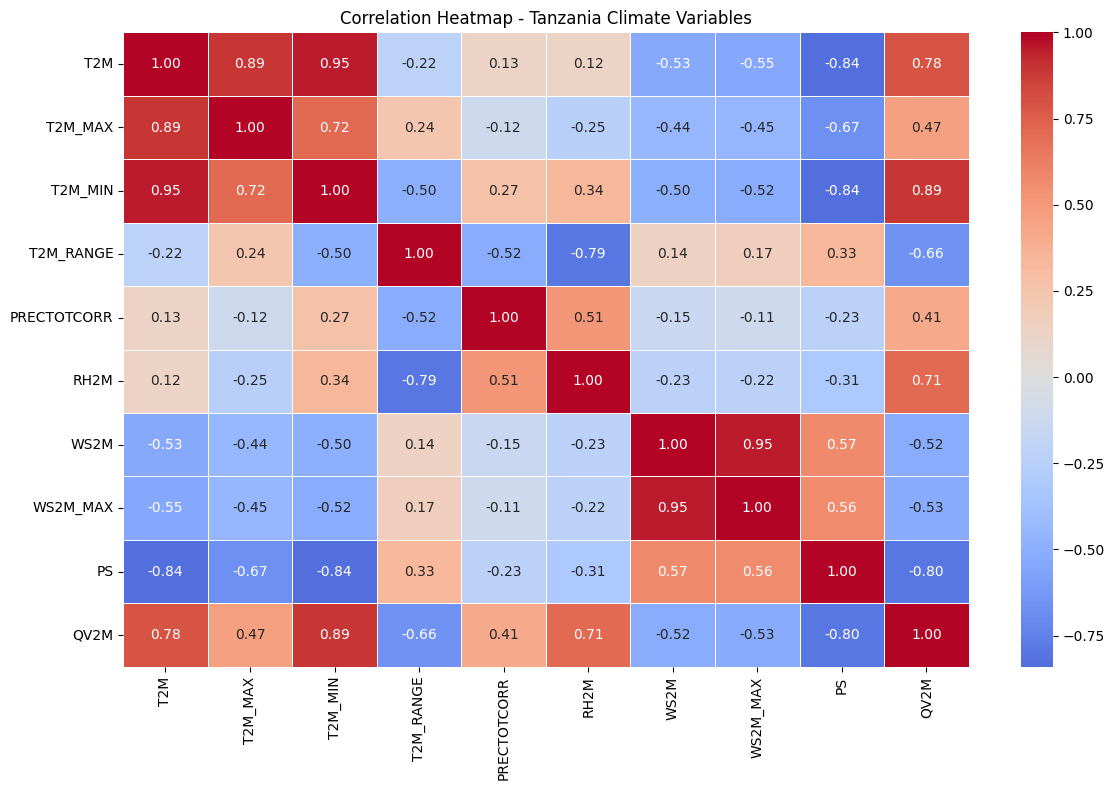

In [12]:
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", 
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap - Tanzania Climate Variables")
plt.tight_layout()
plt.show()

## Correlation Analysis
Key correlations found in Tanzania:

1. T2M and QV2M - strong positive correlation. Warmer air holds 
   more moisture in Tanzania's humid tropical climate.
2. T2M and RH2M - negative correlation. Higher temperatures 
   reduce relative humidity.
3. T2M_MAX and T2M_MIN - strong positive correlation showing 
   consistent warming patterns across day and night.

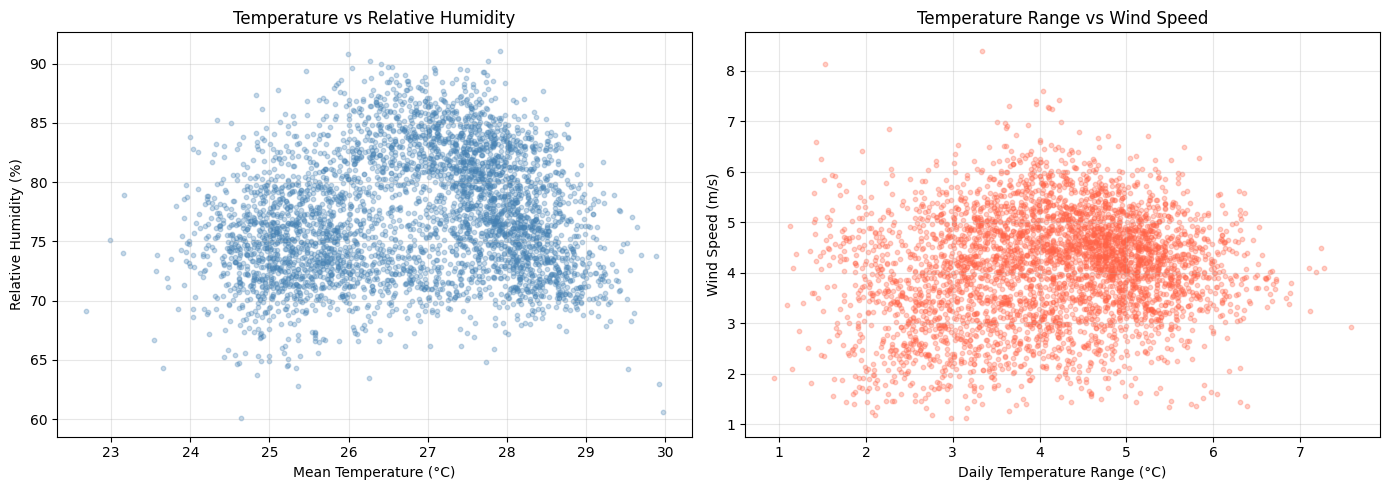

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="steelblue", s=10)
axes[0].set_title("Temperature vs Relative Humidity")
axes[0].set_xlabel("Mean Temperature (°C)")
axes[0].set_ylabel("Relative Humidity (%)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="tomato", s=10)
axes[1].set_title("Temperature Range vs Wind Speed")
axes[1].set_xlabel("Daily Temperature Range (°C)")
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter Plot Analysis

Plot 1 - Temperature vs Relative Humidity:
Tanzania shows high humidity across all temperatures reflecting its 
tropical climate. Even at higher temperatures humidity remains 
elevated compared to Sudan or Ethiopia.

Plot 2 - Temperature Range vs Wind Speed:
Tanzania has smaller daily temperature ranges than Sudan reflecting 
its more stable tropical climate with consistent humidity levels.

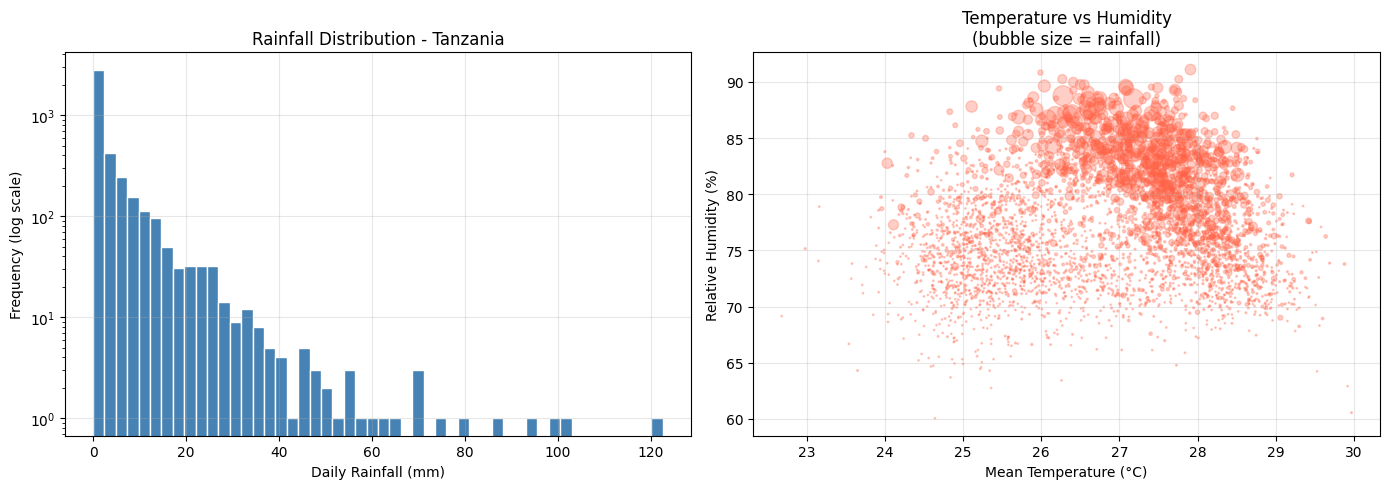

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["PRECTOTCORR"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Rainfall Distribution - Tanzania")
axes[0].set_xlabel("Daily Rainfall (mm)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"] * 2 + 1, alpha=0.3, color="tomato")
axes[1].set_title("Temperature vs Humidity\n(bubble size = rainfall)")
axes[1].set_xlabel("Mean Temperature (°C)")
axes[1].set_ylabel("Relative Humidity (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Distribution Analysis

Rainfall Histogram:
Tanzania's rainfall distribution is right skewed but less extreme 
than Sudan. More days receive moderate rainfall reflecting the 
tropical climate. The maximum of 122.65mm shows intense rain events.

Bubble Chart:
Large bubbles cluster at high humidity levels above 70% confirming 
that heavy rainfall occurs during humid periods. Tanzania shows more 
frequent large bubbles than Sudan or Ethiopia.